# IS 4487 Lab 13

## Learning Objectives
1. Select appropriate variables for a cluster analysis
2. Learn to fit and adjust a cluster analysis model based on similar customer behavioural patterns.
3. Interpret the output of the model

## Lab Tasks
1. Import and prepare data using the *SuperStore Retail Orders* dataset
2. Convert categorical variables to numbers or boolean
3. Fit a K-means model with 5 clusters
4. Display and analyze the results

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/Scripts/lab_13_retailer_cluster_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Superstore Data Dictionary

 ORDER VARIABLES:
 - Order ID
 - Order Date
 - Order Year Month - Year and month of the order
 - Order Type - Was the order completed at a store or online? (Retail, Online)
 - Quantity - Quantity ordered for the product

 CUSTOMER VARIABLES:
 - Customer Name
 - City
 - State Province
 - Email


PRODUCT VARIABLES:
 - Product Name
 - Product Line - Category of the product (i.e. Bikes Phones)
 - Product Price - Price in US Dollars
 - Product Status - Current status of the product (Active, Inactive)

## Load Libraries

➡️ Assignment Tasks
- Load any other necessary libraries, in addition to those below

In [35]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Data into Dataframe

➡️ Assignment Tasks
- Import data from the SuperStore retail dataset into a dataframe (in GitHub go to Labs > DataSets)
- Describe or profile the dataframe

In [21]:
df = pd.read_csv('https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/Labs/DataSets/superstore_retail_orders.csv')
df.describe()

,order_id,quantity,product_price
count,56043.000000,56004.000000,56043.000000
mean,61668.410578,3.348582,6198.309433
std,7508.142486,422.654112,35784.965255
min,45079.000000,1.000000,2.290000
25%,55644.500000,1.000000,7.950000
50%,61870.000000,1.000000,475.600000
75%,68097.000000,2.000000,914.620000
max,74147.000000,100000.000000,235481.000000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56043 entries, 0 to 56042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          56043 non-null  int64  
 1   order_date        56011 non-null  object 
 2   order_year_month  56011 non-null  object 
 3   customer_name     56043 non-null  object 
 4   city              55569 non-null  object 
 5   state_province    55569 non-null  object 
 6   email             56043 non-null  object 
 7   order_type        56043 non-null  object 
 8   quantity          56004 non-null  float64
 9   product_name      56043 non-null  object 
 10  product_line      56043 non-null  object 
 11  product_price     56043 non-null  float64
 12  product_status    56043 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 5.6+ MB


In [23]:
df.head()

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,product_line,product_price,product_status
0,51188,2023-07-01,2023-07,Audrey Blanco,North Cherylmouth,New Hampshire,audrey_blanco@email.com,Retail,3.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
1,51187,2023-07-01,2023-07,Isaac Allen,Traceyland,West Virginia,isaac_allen@email.com,Online,4.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
2,51199,2023-07-02,2023-07,Ian Morgan,Dylanberg,South Dakota,ian_morgan@email.com,Online,5.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
3,51241,2023-07-04,2023-07,Alexa Bell,Lake Tracytown,Wisconsin,alexa_bell@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active
4,51297,2023-07-08,2023-07,Casey Diaz,Byrdchester,Mississippi,casey_diaz@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active


## Prepare Data
Note that K-Means requires that all variables be numbers or boolean.  No categorical variables are allowed.

➡️ Assignment Tasks
- Copy your dataframe into a new version, so that the original data is still available
- Create any needed variables, such as month of year and total_amount.  
- Filter out any incomplete orders
- Convert the OrderType and Product Line variables to multiple one-hot variables using OneHotEncoder (one variable for each value)
- Remove any variables that will be not be included (hint: only numeric variables are allowed)
- Remove any outliers that will cause a cluster to be created for the few records with the outlier value (pay close attention to dates, quantities and prices)

*Notes:*
- There is no need to split the data for cluster analysis.  Why is that the case?
- You should think carefully about which variables to include.  They should be independent and numeric, and have some behavioural aspect for customers.  A date, for example, cannot be used unless it is somehow converted to a number.  

In [24]:
#create new dataframe and do any number conversion
df2 = df.copy()
df2['order_month'] = df2['order_year_month'].str.split('-').str[1].str.strip().replace('', np.nan).fillna(0).astype(int)
#total_amount variable
df2['total_amount'] = df2['quantity'] * df2['product_price']
df2.head()

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,product_line,product_price,product_status,order_month,total_amount
0,51188,2023-07-01,2023-07,Audrey Blanco,North Cherylmouth,New Hampshire,audrey_blanco@email.com,Retail,3.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,7,1949.97
1,51187,2023-07-01,2023-07,Isaac Allen,Traceyland,West Virginia,isaac_allen@email.com,Online,4.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,7,2599.96
2,51199,2023-07-02,2023-07,Ian Morgan,Dylanberg,South Dakota,ian_morgan@email.com,Online,5.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,7,3249.95
3,51241,2023-07-04,2023-07,Alexa Bell,Lake Tracytown,Wisconsin,alexa_bell@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,7,649.99
4,51297,2023-07-08,2023-07,Casey Diaz,Byrdchester,Mississippi,casey_diaz@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,7,649.99


In [25]:
#filter records with incomplete or invalid data
df2.dropna(inplace=True)

In [26]:
#one-hot encoding
enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(df2[['order_type', 'product_line']])
num_df = enc.transform(df2[['order_type', 'product_line']]).toarray()
num_df = pd.DataFrame(num_df, columns=enc.get_feature_names_out(['order_type', 'product_line']))
df2 = pd.concat([df2, num_df], axis=1)
df2.head()

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,...,order_type_Retail,product_line_Accessories,product_line_Bikes,product_line_Cameras,product_line_Clothing,product_line_Electronics,product_line_Laptop,product_line_Mobile,product_line_OfficeProducts,product_line_Projector
0,51188.0,2023-07-01,2023-07,Audrey Blanco,North Cherylmouth,New Hampshire,audrey_blanco@email.com,Retail,3.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51187.0,2023-07-01,2023-07,Isaac Allen,Traceyland,West Virginia,isaac_allen@email.com,Online,4.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,51199.0,2023-07-02,2023-07,Ian Morgan,Dylanberg,South Dakota,ian_morgan@email.com,Online,5.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,51241.0,2023-07-04,2023-07,Alexa Bell,Lake Tracytown,Wisconsin,alexa_bell@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,51297.0,2023-07-08,2023-07,Casey Diaz,Byrdchester,Mississippi,casey_diaz@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [29]:
#remove outliers
Q1_quantity = df2['quantity'].quantile(0.25)
Q3_quantity = df2['quantity'].quantile(0.75)
IQR_quantity = Q3_quantity - Q1_quantity
Q1_price = df2['product_price'].quantile(0.25)
Q3_price = df2['product_price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_quantity = Q1_quantity - 1.5 * IQR_quantity
upper_bound_quantity = Q3_quantity + 1.5 * IQR_quantity
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price
df2 = df2[
    (df2['quantity'] >= lower_bound_quantity) & (df2['quantity'] <= upper_bound_quantity) &
    (df2['product_price'] >= lower_bound_price) & (df2['product_price'] <= upper_bound_price)
]

In [31]:
#eliminate any variables that you don't want to use in the model (select your final variable set)
selected_columns = ['quantity', 'product_price', 'order_month', 'total_amount',
                    'order_type_Online', 'order_type_Retail',
                    'product_line_Accessories', 'product_line_Bikes',
                    'product_line_Cameras', 'product_line_Clothing',
                    'product_line_Electronics', 'product_line_Laptop','product_line_Mobile',
                    'product_line_OfficeProducts','product_line_Projector']
df_model = df2[selected_columns]

## Create Model

For more info on K-means in python, see: https://realpython.com/k-means-clustering-python/

➡️ Assignment Tasks
- Fit the K-means model using the Kmeans method
- Use 5 clusters

In [34]:
#create and fit model
df_model = df_model.dropna()
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(df_model)

KMeans(n_clusters=5, random_state=0)

## Analyze the Clusters

➡️ Assignment Tasks
- create at least two visualizations to show the clusters (try a Bar Chart, Pair Plot or Scatter Plot)
- Display the cluster and mean values for each of the variables

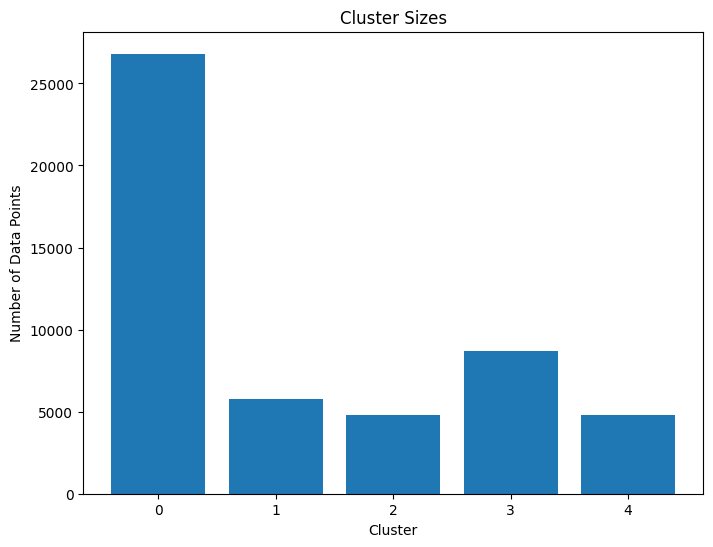

In [38]:
#visualization #1
df_model.loc[:,'cluster'] = kmeans.labels_
cluster_sizes = df_model['cluster'].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(cluster_sizes.index, cluster_sizes.values)
plt.xlabel('Cluster')
plt.ylabel('Number of Data Points')
plt.title('Cluster Sizes')
plt.show()

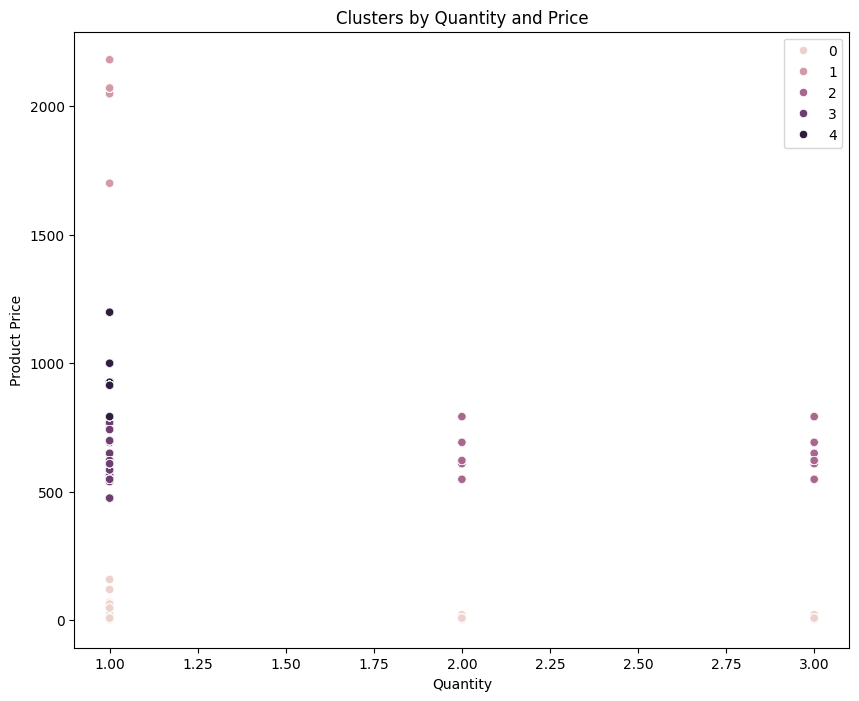

In [46]:
#visualization #2
plt.figure(figsize=(10, 8))
sns.scatterplot(x='quantity', y='product_price', hue=kmeans.labels_, data=df_model)
plt.title('Clusters by Quantity and Price')
plt.xlabel('Quantity')
plt.ylabel('Product Price')
plt.show()

In [41]:
#cluster summary statistics
cluster_means = df_model.groupby('cluster').mean()
cluster_means

,quantity,product_price,order_month,total_amount,order_type_Online,order_type_Retail,product_line_Accessories,product_line_Bikes,product_line_Cameras,product_line_Clothing,product_line_Electronics,product_line_Laptop,product_line_Mobile,product_line_OfficeProducts,product_line_Projector
cluster,,,,,,,,,,,,,,,
0,1.785117,18.808580,6.353823,23.973640,0.498918,0.501082,0.710668,0.000000,0.000000,0.183215,0.030959,0.000000,0.000000,0.075159,0.000000
1,1.000000,2034.514929,6.301486,2034.514929,0.390290,0.609710,0.000000,0.915688,0.035764,0.000000,0.000000,0.000000,0.011230,0.000000,0.037319
2,2.139269,677.807985,6.399958,1450.526357,0.503528,0.496472,0.084682,0.000000,0.000000,0.000000,0.915110,0.000000,0.000208,0.000000,0.000000
3,1.000000,590.544853,6.335940,590.544853,0.461645,0.538355,0.003105,0.205405,0.151236,0.000000,0.586659,0.049339,0.004255,0.000000,0.000000
4,1.000000,949.460196,6.476756,949.460196,0.456118,0.543882,0.005837,0.093392,0.000000,0.000000,0.655410,0.000000,0.245362,0.000000,0.000000
